# Hen Pose Estimation — YOLOv8 Training
**Dataset:** pose-v1 | 10 keypoints per hen  
**Keypoints:** tail_base · tail_tip · left_hock · right_hock · left_foot · right_foot · neck_back · middle_back · comb · beak

## 1. Install & verify environment

In [ ]:
!pip install -q --upgrade ultralytics

import torch
import ultralytics
ultralytics.checks()

print(f"PyTorch : {torch.__version__}")
print(f"CUDA    : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU     : {torch.cuda.get_device_name(0)}")
    print(f"VRAM    : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

## 2. Dataset path
Change `DATASET_ROOT` if you move the folder (e.g. on Colab set it to `/content/pose-v1`).

In [6]:
from pathlib import Path
import yaml

DATASET_ROOT = Path("/Users/ogbi/School/Research/poultry-vision/pose-v2")   # <-- change for Colab/other machine

data_yaml = DATASET_ROOT / "data.yaml"
assert data_yaml.exists(), f"Not found: {data_yaml}"

with open(data_yaml) as f:
    cfg = yaml.safe_load(f)

train_imgs = list((DATASET_ROOT / "images" / "train").glob("*"))
val_imgs   = list((DATASET_ROOT / "images" / "val").glob("*"))
train_lbls = list((DATASET_ROOT / "labels" / "train").glob("*.txt"))
val_lbls   = list((DATASET_ROOT / "labels" / "val").glob("*.txt"))

print(f"Train  images / labels : {len(train_imgs)} / {len(train_lbls)}")
print(f"Val    images / labels : {len(val_imgs)} / {len(val_lbls)}")
print(f"Keypoints per instance : {cfg['kpt_shape'][0]}")
print(f"Classes                : {cfg['names']}")
print(f"data.yaml path field   : {cfg['path']}  (should be '.' for portability)")

Train  images / labels : 79 / 79
Val    images / labels : 20 / 20
Keypoints per instance : 10
Classes                : {0: 'hen'}
data.yaml path field   : .  (should be '.' for portability)


## 3. Spot-check labels on a few images

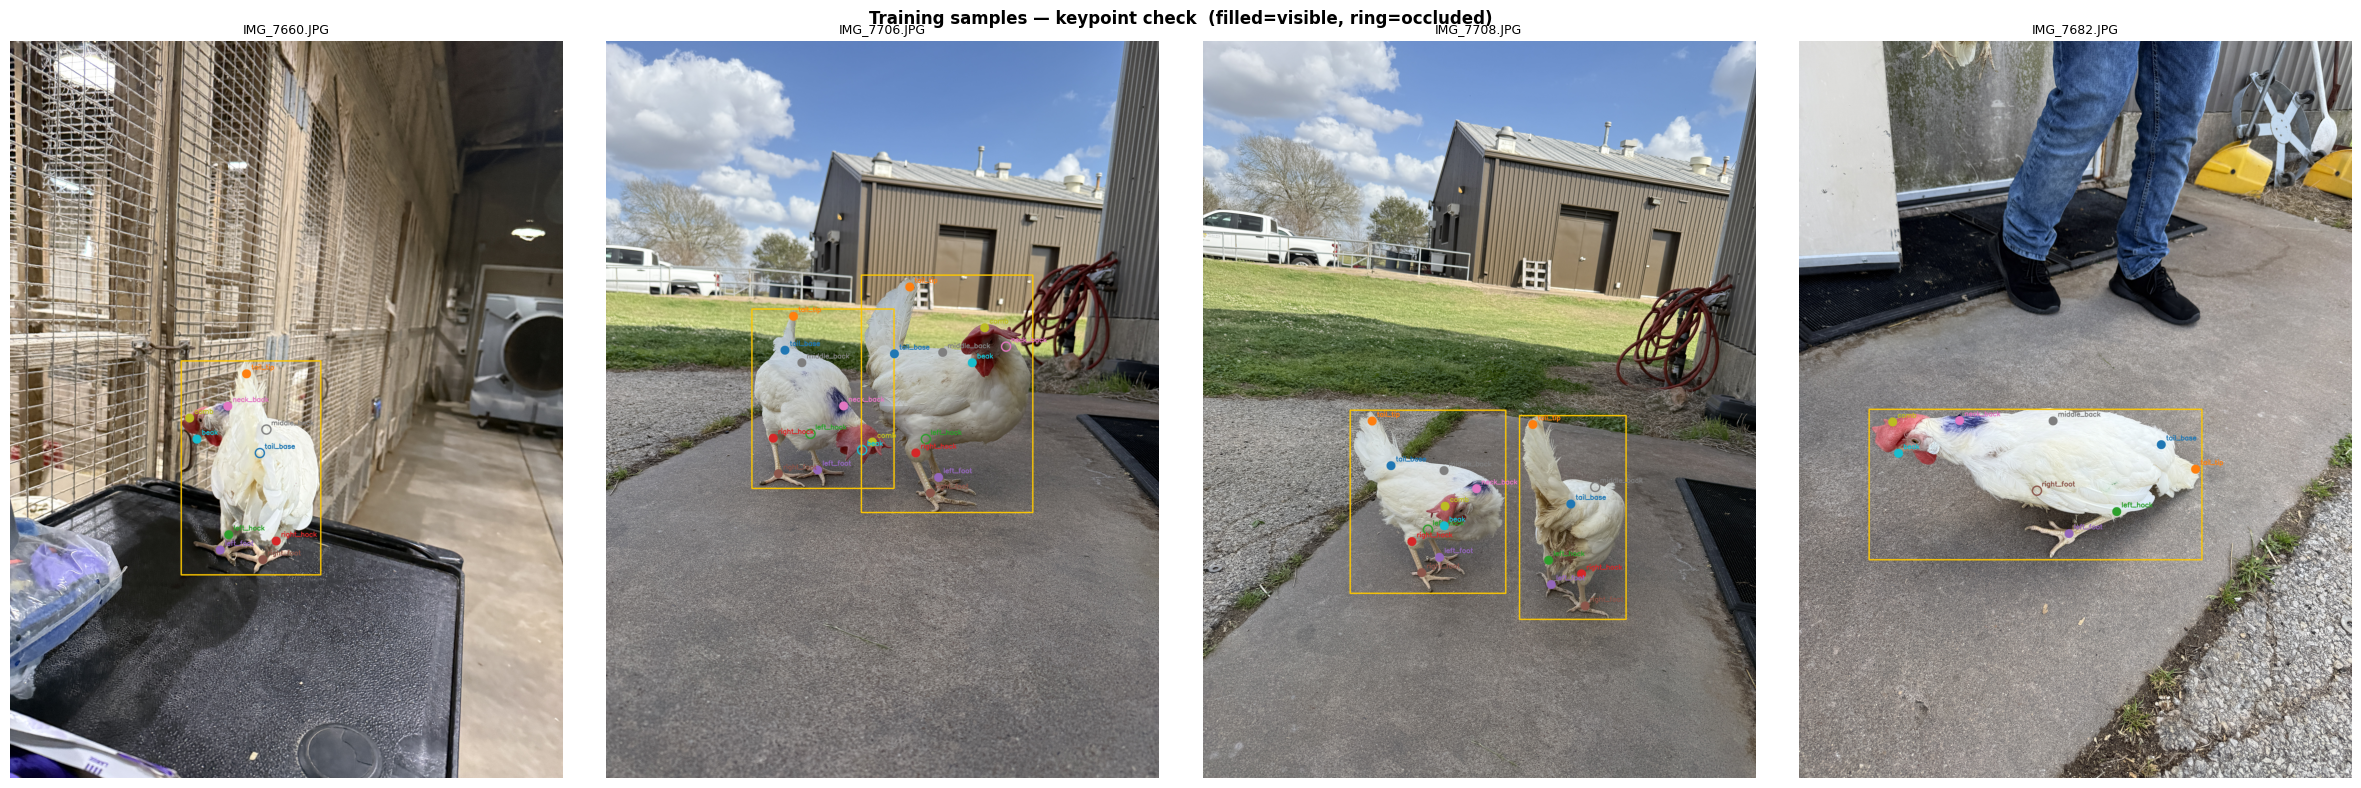

In [9]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import random
from PIL import Image, ImageOps

KPT_NAMES = cfg["kpt_names"][0]
COLORS = (plt.cm.tab10(np.linspace(0, 1, len(KPT_NAMES)))[:, :3] * 255).astype(int)

def draw_pose(img_path, lbl_path):
    # PIL with exif_transpose so portrait iPhone photos load correctly
    pil_img = ImageOps.exif_transpose(Image.open(str(img_path))).convert("RGB")
    img = np.array(pil_img)
    h, w = img.shape[:2]

    # Scale marker sizes proportionally so they're visible on any resolution
    r          = max(10, w // 120)
    thickness  = max(3,  w // 400)
    font_scale = max(0.6, w / 2500)
    font_thick = max(2, w // 800)

    with open(lbl_path) as f:
        for line in f:
            v = list(map(float, line.split()))
            cx, cy, bw, bh = v[1]*w, v[2]*h, v[3]*w, v[4]*h
            x1, y1 = int(cx - bw/2), int(cy - bh/2)
            x2, y2 = int(cx + bw/2), int(cy + bh/2)
            cv2.rectangle(img, (x1, y1), (x2, y2), (255, 200, 0), thickness)

            kps = v[5:]
            for i in range(0, len(kps), 3):
                kx, ky, vis = kps[i]*w, kps[i+1]*h, int(kps[i+2])
                if vis == 0:
                    continue
                c = tuple(COLORS[i // 3].tolist())
                # filled circle for visible (2), ring for occluded (1)
                if vis == 2:
                    cv2.circle(img, (int(kx), int(ky)), r, c, -1)
                else:
                    cv2.circle(img, (int(kx), int(ky)), r, c, thickness)
                cv2.putText(img, KPT_NAMES[i // 3],
                            (int(kx) + r + 2, int(ky) - r),
                            cv2.FONT_HERSHEY_SIMPLEX, font_scale, c, font_thick,
                            cv2.LINE_AA)
    return img

samples = random.sample(train_imgs, min(4, len(train_imgs)))
fig, axes = plt.subplots(1, len(samples), figsize=(24, 8))
for ax, p in zip(axes, samples):
    lbl = DATASET_ROOT / "labels" / "train" / (p.stem + ".txt")
    ax.imshow(draw_pose(p, lbl))
    ax.set_title(p.name, fontsize=9)
    ax.axis("off")
plt.suptitle("Training samples — keypoint check  (filled=visible, ring=occluded)",
             fontweight="bold", fontsize=12)
plt.tight_layout()
plt.show()

## 4. Training

| VRAM | `batch` | `imgsz` |
|------|---------|----------|
| 4 GB | 4 | 640 |
| 8 GB | 8 | 640 |
| 16 GB | 16 | 800 |
| 24 GB+ | 32 | 1024 |

> **Aspect ratios:** YOLO letterboxes every image to `imgsz × imgsz` and adjusts the normalized coordinates automatically — no preprocessing required.

In [11]:
from ultralytics import YOLO

model = YOLO("yolov8n-pose.pt")   # nano — swap to yolov8s-pose.pt for more capacity

# Force an absolute dataset root so Ultralytics does not fallback to its global datasets dir
with open(data_yaml) as f:
    train_cfg = yaml.safe_load(f)

train_cfg["path"] = str(DATASET_ROOT.resolve())
data_yaml_abs = DATASET_ROOT / "data.ultra.abs.yaml"
with open(data_yaml_abs, "w") as f:
    yaml.safe_dump(train_cfg, f, sort_keys=False)

results = model.train(
    data      = str(data_yaml_abs),
    epochs    = 50,
    imgsz     = 640,
    batch     = 8,          # adjust to VRAM
    patience  = 50,         # keep all 50 epochs; lower to ~15 after you see convergence
    optimizer = "AdamW",
    lr0       = 0.001,
    lrf       = 0.01,
    warmup_epochs = 3,
    # Augmentation — critical for a 99-image dataset
    hsv_h     = 0.015,
    hsv_s     = 0.5,
    hsv_v     = 0.3,
    fliplr    = 0.5,
    flipud    = 0.0,        # hens are always upright
    mosaic    = 0.5,
    mixup     = 0.1,
    degrees   = 10.0,
    translate = 0.1,
    scale     = 0.5,
    project   = "runs/pose",
    name      = "hen_pose_v1",
    exist_ok  = True,
    plots     = True,
)

best_weights = Path(results.save_dir) / "weights" / "best.pt"
print(f"\nTraining complete.")
print(f"Best weights : {best_weights}")

New https://pypi.org/project/ultralytics/8.4.30 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.3.63 🚀 Python-3.11.14 torch-2.2.2 CPU (Apple M4)
engine/trainer: task=pose, mode=train, model=yolov8n-pose.pt, data=/Users/ogbi/School/Research/poultry-vision/pose-v2/data.yaml, epochs=50, time=None, patience=50, batch=8, imgsz=640, save=True, save_period=-1, cache=False, device=None, workers=8, project=runs/pose, name=hen_pose_v1, exist_ok=True, pretrained=True, optimizer=AdamW, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_masks=False, embed=Non

RuntimeError: Dataset '/Users/ogbi/School/Research/poultry-vision/pose-v2/data.yaml' error ❌ 
Dataset '/Users/ogbi/School/Research/poultry-vision/pose-v2/data.yaml' images not found ⚠️, missing path '/Users/ogbi/School/Research/datasets/images/val'
Note dataset download directory is '/Users/ogbi/School/Research/datasets'. You can update this in '/Users/ogbi/Library/Application Support/yolov12/settings.json'

In [12]:
import tempfile, copy
from ultralytics import YOLO

# Ultralytics resolves a relative 'path:' field in data.yaml against its own
# global datasets directory, NOT against the data.yaml file location.
# We patch it to the absolute DATASET_ROOT using a temporary yaml so the
# data.yaml on disk stays portable and we don't hard-code any paths there.
_cfg = copy.deepcopy(cfg)
_cfg["path"] = str(DATASET_ROOT.resolve())
_tmp_yaml = Path(tempfile.mktemp(suffix=".yaml"))
with open(_tmp_yaml, "w") as _f:
    yaml.dump(_cfg, _f, default_flow_style=False, sort_keys=False)

model = YOLO("yolov8n-pose.pt")   # nano — swap to yolov8s-pose.pt for more capacity

results = model.train(
    data      = str(_tmp_yaml),
    epochs    = 50,
    imgsz     = 640,
    batch     = 8,          # adjust to VRAM
    patience  = 50,
    optimizer = "AdamW",
    lr0       = 0.001,
    lrf       = 0.01,
    warmup_epochs = 3,
    # Augmentation — critical for a 99-image dataset
    hsv_h     = 0.015,
    hsv_s     = 0.5,
    hsv_v     = 0.3,
    fliplr    = 0.5,
    flipud    = 0.0,        # hens are always upright
    mosaic    = 0.5,
    mixup     = 0.1,
    degrees   = 10.0,
    translate = 0.1,
    scale     = 0.5,
    project   = "runs/pose",
    name      = "hen_pose_v1",
    exist_ok  = True,
    plots     = True,
)

_tmp_yaml.unlink(missing_ok=True)

best_weights = Path(results.save_dir) / "weights" / "best.pt"
print(f"\nTraining complete.")
print(f"Best weights : {best_weights}")


New https://pypi.org/project/ultralytics/8.4.30 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.3.63 🚀 Python-3.11.14 torch-2.2.2 CPU (Apple M4)
engine/trainer: task=pose, mode=train, model=yolov8n-pose.pt, data=/var/folders/kq/5nl99ybd1wl39cn_myjfdy0h0000gn/T/tmpe7cfn7hy.yaml, epochs=50, time=None, patience=50, batch=8, imgsz=640, save=True, save_period=-1, cache=False, device=None, workers=8, project=runs/pose, name=hen_pose_v1, exist_ok=True, pretrained=True, optimizer=AdamW, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_masks=False, embe

train: Scanning /Users/ogbi/School/Research/poultry-vision/pose-v2/labels/train... 79 images, 2 backgrounds, 0 corrupt: 100%|██████████| 79/79 [00:00<00:00, 2650.93it/s]

train: New cache created: /Users/ogbi/School/Research/poultry-vision/pose-v2/labels/train.cache


albumentations: Blur(p=0.01, blur_limit=(3, 7)), MedianBlur(p=0.01, blur_limit=(3, 7)), ToGray(p=0.01, num_output_channels=3, method='weighted_average'), CLAHE(p=0.01, clip_limit=(1.0, 4.0), tile_grid_size=(8, 8))


/Users/ogbi/miniconda3/envs/poultry/lib/python3.11/site-packages/albumentations/__init__.py:28: UserWarning: A new version of Albumentations is available: '2.0.8' (you have '2.0.4'). Upgrade using: pip install -U albumentations. To disable automatic update checks, set the environment variable NO_ALBUMENTATIONS_UPDATE to 1.
  check_for_updates()
/Users/ogbi/School/Research/poultry-vision/ultralytics/data/augment.py:1853: UserWarning: Argument(s) 'quality_lower' are not valid for transform ImageCompression
  A.ImageCompression(quality_lower=75, p=0.0),
val: Scanning /Users/ogbi/School/Research/poultry-vision/pose-v2/labels/val... 20 images, 0 backgrounds, 0 corrupt: 100%|██████████| 20/20 [00:00<00:00, 3603.04it/s]

...


      50/50         0G     0.9391      4.208     0.5913     0.5217      1.169         18        640: 100%|██████████| 10/10 [00:17<00:00,  1.79s/it]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Pose(P          R      mAP50  mAP50-95): 100%|██████████| 2/2 [00:04<00:00,  2.40s/it]

                   all         20         81      0.833      0.753      0.802      0.466      0.678      0.407      0.389     0.0927



50 epochs completed in 0.316 hours.
Optimizer stripped from runs/pose/hen_pose_v1/weights/last.pt, 6.6MB
Optimizer stripped from runs/pose/hen_pose_v1/weights/best.pt, 6.6MB

Validating runs/pose/hen_pose_v1/weights/best.pt...
Ultralytics 8.3.63 🚀 Python-3.11.14 torch-2.2.2 CPU (Apple M4)
YOLOv8n-pose summary (fused): 187 layers, 3,154,073 parameters, 0 gradients, 8.6 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Pose(P          R      mAP50  mAP50-95): 100%|██████████| 2/2 [00:04<00:00,  2.34s/it]


                   all         20         81      0.878      0.753      0.817      0.489       0.65      0.407       0.37     0.0771
Speed: 1.0ms preprocess, 135.9ms inference, 0.0ms loss, 0.4ms postprocess per image
Results saved to runs/pose/hen_pose_v1

Training complete.
Best weights : runs/pose/hen_pose_v1/weights/best.pt


## 5. Evaluate on validation set

In [14]:
model_best = YOLO(str(best_weights))

# Patch validation yaml so Ultralytics uses absolute dataset root
_cfg_val = dict(cfg)
_cfg_val["path"] = str(DATASET_ROOT.resolve())
data_yaml_val_abs = DATASET_ROOT / "data.ultra.abs.val.yaml"
with open(data_yaml_val_abs, "w") as f:
	yaml.safe_dump(_cfg_val, f, sort_keys=False)

metrics = model_best.val(data=str(data_yaml_val_abs), plots=True)

print(f"Box  mAP50       : {metrics.box.map50:.4f}")
print(f"Box  mAP50-95    : {metrics.box.map:.4f}")
print(f"Pose mAP50       : {metrics.pose.map50:.4f}")
print(f"Pose mAP50-95    : {metrics.pose.map:.4f}")

Ultralytics 8.3.63 🚀 Python-3.11.14 torch-2.2.2 CPU (Apple M4)
YOLOv8n-pose summary (fused): 187 layers, 3,154,073 parameters, 0 gradients, 8.6 GFLOPs


val: Scanning /Users/ogbi/School/Research/poultry-vision/pose-v2/labels/val.cache... 20 images, 0 backgrounds, 0 corrupt: 100%|██████████| 20/20 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Pose(P          R      mAP50  mAP50-95): 100%|██████████| 2/2 [00:04<00:00,  2.38s/it]


                   all         20         81      0.878      0.753      0.817      0.489       0.65      0.407       0.37     0.0771
Speed: 1.9ms preprocess, 139.6ms inference, 0.0ms loss, 0.4ms postprocess per image
Results saved to /Users/ogbi/School/Research/poultry-vision/runs/pose/val2
Box  mAP50       : 0.8172
Box  mAP50-95    : 0.4886
Pose mAP50       : 0.3700
Pose mAP50-95    : 0.0771


In [15]:
model_best = YOLO(str(best_weights))

# Patch path to absolute (same reason as training cell)
_cfg_val = copy.deepcopy(cfg)
_cfg_val["path"] = str(DATASET_ROOT.resolve())
_tmp_yaml_val = Path(tempfile.mktemp(suffix=".yaml"))
with open(_tmp_yaml_val, "w") as _f:
    yaml.dump(_cfg_val, _f, default_flow_style=False, sort_keys=False)

metrics = model_best.val(data=str(_tmp_yaml_val), plots=True)
_tmp_yaml_val.unlink(missing_ok=True)

print(f"Box  mAP50       : {metrics.box.map50:.4f}")
print(f"Box  mAP50-95    : {metrics.box.map:.4f}")
print(f"Pose mAP50       : {metrics.pose.map50:.4f}")
print(f"Pose mAP50-95    : {metrics.pose.map:.4f}")

Ultralytics 8.3.63 🚀 Python-3.11.14 torch-2.2.2 CPU (Apple M4)
YOLOv8n-pose summary (fused): 187 layers, 3,154,073 parameters, 0 gradients, 8.6 GFLOPs


val: Scanning /Users/ogbi/School/Research/poultry-vision/pose-v2/labels/val.cache... 20 images, 0 backgrounds, 0 corrupt: 100%|██████████| 20/20 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Pose(P          R      mAP50  mAP50-95): 100%|██████████| 2/2 [00:04<00:00,  2.38s/it]


                   all         20         81      0.878      0.753      0.817      0.489       0.65      0.407       0.37     0.0771
Speed: 1.2ms preprocess, 139.0ms inference, 0.0ms loss, 0.4ms postprocess per image
Results saved to /Users/ogbi/School/Research/poultry-vision/runs/pose/val3
Box  mAP50       : 0.8172
Box  mAP50-95    : 0.4886
Pose mAP50       : 0.3700
Pose mAP50-95    : 0.0771


## 6. Training curves

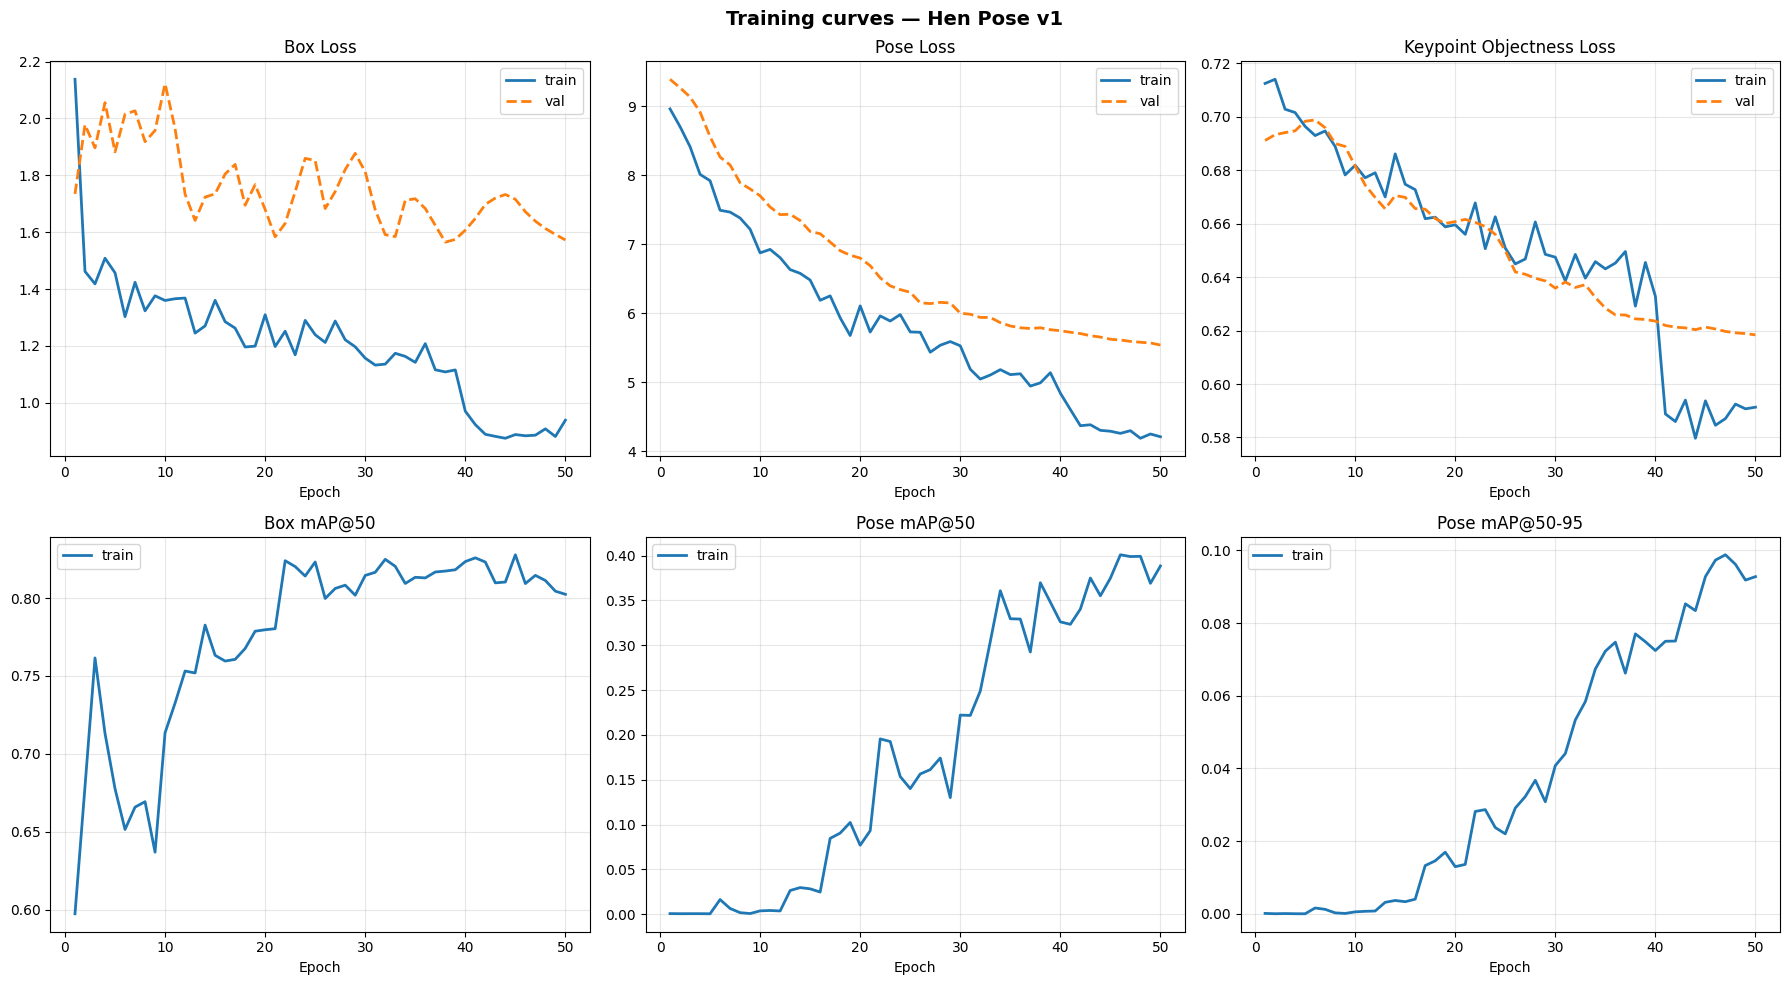

Saved: training_curves.png


In [16]:
import pandas as pd

df = pd.read_csv(Path(results.save_dir) / "results.csv")
df.columns = df.columns.str.strip()

plots = [
    ("train/box_loss",      "val/box_loss",      "Box Loss"),
    ("train/pose_loss",     "val/pose_loss",     "Pose Loss"),
    ("train/kobj_loss",     "val/kobj_loss",     "Keypoint Objectness Loss"),
    ("metrics/mAP50(B)",    None,                "Box mAP@50"),
    ("metrics/mAP50(P)",    None,                "Pose mAP@50"),
    ("metrics/mAP50-95(P)", None,                "Pose mAP@50-95"),
]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("Training curves — Hen Pose v1", fontsize=14, fontweight="bold")
for ax, (tc, vc, title) in zip(axes.flat, plots):
    if tc in df.columns:
        ax.plot(df["epoch"], df[tc], label="train", linewidth=2)
    if vc and vc in df.columns:
        ax.plot(df["epoch"], df[vc], label="val", linewidth=2, linestyle="--")
    ax.set_title(title)
    ax.set_xlabel("Epoch")
    ax.legend()
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("training_curves.png", dpi=150)
plt.show()
print("Saved: training_curves.png")

## 7. Predictions on validation images

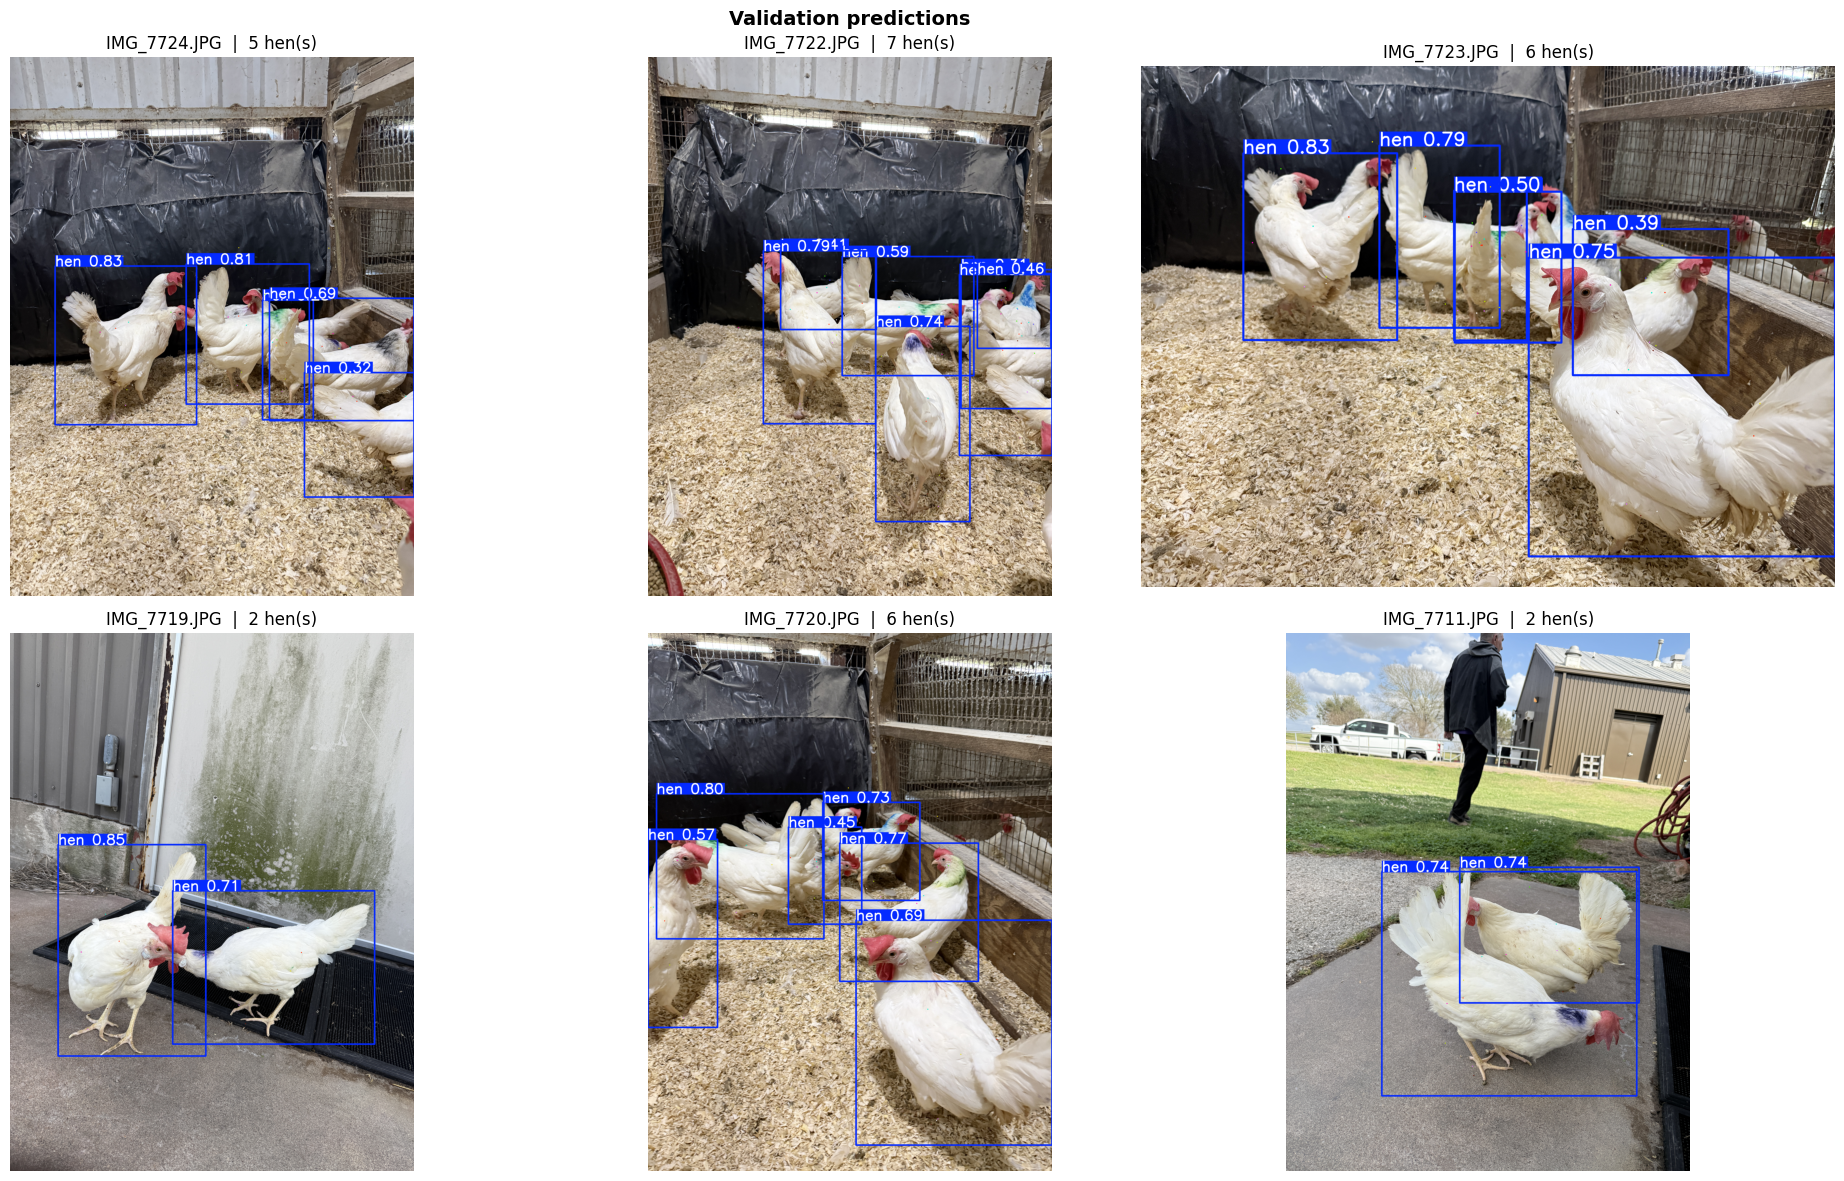

Saved: val_predictions.png


In [17]:
samples = random.sample(val_imgs, min(6, len(val_imgs)))
preds = model_best.predict(source=samples, conf=0.25, imgsz=640, save=False, verbose=False)

fig, axes = plt.subplots(2, 3, figsize=(20, 12))
fig.suptitle("Validation predictions", fontsize=14, fontweight="bold")
for ax, r in zip(axes.flat, preds):
    ax.imshow(cv2.cvtColor(r.plot(), cv2.COLOR_BGR2RGB))
    ax.set_title(f"{Path(r.path).name}  |  {len(r.boxes)} hen(s)")
    ax.axis("off")
plt.tight_layout()
plt.savefig("val_predictions.png", dpi=150)
plt.show()
print("Saved: val_predictions.png")

## 8. Per-keypoint visibility breakdown
Useful for spotting which keypoints are consistently missed or occluded.

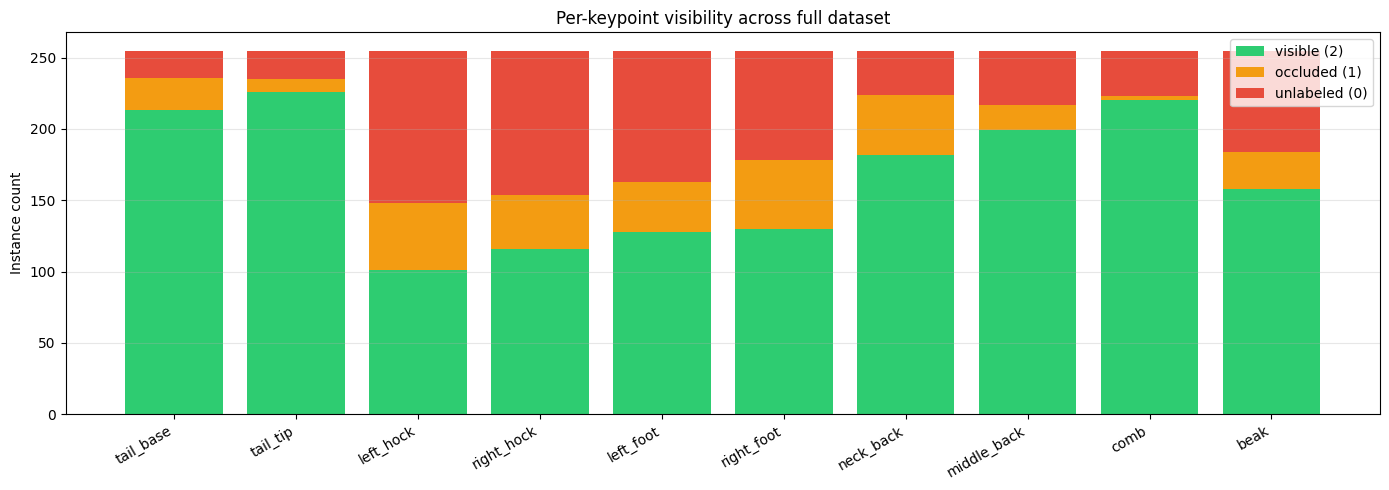

Saved: keypoint_visibility.png


In [18]:
from collections import defaultdict

vis_counts = defaultdict(lambda: [0, 0, 0])  # kpt_name -> [unlabeled, occluded, visible]

for lbl_path in list(train_lbls) + list(val_lbls):
    with open(lbl_path) as f:
        for line in f:
            v = list(map(float, line.split()))
            kps = v[5:]
            for i in range(0, len(kps), 3):
                name = KPT_NAMES[i // 3]
                vis  = int(kps[i + 2])
                vis_counts[name][vis] += 1

names  = KPT_NAMES
unlab  = [vis_counts[n][0] for n in names]
occl   = [vis_counts[n][1] for n in names]
visib  = [vis_counts[n][2] for n in names]
x      = np.arange(len(names))

fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(x, visib, label="visible (2)",   color="#2ecc71")
ax.bar(x, occl,  bottom=visib,          label="occluded (1)", color="#f39c12")
ax.bar(x, unlab, bottom=[v+o for v,o in zip(visib,occl)], label="unlabeled (0)", color="#e74c3c")
ax.set_xticks(x)
ax.set_xticklabels(names, rotation=30, ha="right")
ax.set_ylabel("Instance count")
ax.set_title("Per-keypoint visibility across full dataset")
ax.legend()
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("keypoint_visibility.png", dpi=150)
plt.show()
print("Saved: keypoint_visibility.png")

## 9. Export best model to ONNX
For deployment on any machine without a GPU (Raspberry Pi, inference server, etc.).

In [ ]:
model_best.export(format="onnx", imgsz=640, simplify=True)
onnx_path = str(best_weights).replace(".pt", ".onnx")
print(f"PT   : {best_weights}")
print(f"ONNX : {onnx_path}")